In [1]:
import numpy as np
import pandas as pd
import os 
import glob as gb
from tqdm import tqdm
import matplotlib.pyplot as plt 

import torch
from torch import nn 
from torch.utils.data import Dataset , DataLoader
import torchvision as tv
from torchvision import tv_tensors
from torchvision.transforms import v2 as T
import torchmetrics as tm

# Read Dataset


In [2]:
BASE_DIR = '/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset'

In [3]:
class_folders = [f for f in os.listdir(BASE_DIR) if not (f.endswith('.xlsx') or f.endswith('.txt'))]
class_folders

['Normal', 'Lung_Opacity', 'Viral Pneumonia', 'COVID']

In [4]:
id2label = {k:v for k,v in enumerate(class_folders)}
label2id = {v:k for k,v in enumerate(class_folders)}
label2id

{'Normal': 0, 'Lung_Opacity': 1, 'Viral Pneumonia': 2, 'COVID': 3}

In [5]:
def read_dataset(data_dir) : 
    data = []
    for class_name in tqdm(class_folders):
        images_dir = os.path.join(data_dir, class_name, 'images')
        masks_dir = os.path.join(data_dir, class_name, 'masks')
        
        if os.path.exists(images_dir) and os.path.exists(masks_dir):
            image_filenames = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
            
            for img_name in image_filenames:
                img_path = os.path.join(images_dir, img_name)
                mask_path = os.path.join(masks_dir, img_name) 
                
                if os.path.exists(mask_path):
                    data.append({
                        'img_path': img_path,
                        'mask_path': mask_path,
                        'class': class_name,
                        'class_id': label2id[class_name]
                    }) 

    return pd.DataFrame(data)

In [6]:
df = read_dataset(BASE_DIR)
df = df.sample(frac=1, random_state=101).reset_index(drop=True)
print(df.head())
print(f"\nTotal samples: {len(df)}")

100%|██████████| 4/4 [01:11<00:00, 17.77s/it]

                                            img_path  \
0  /kaggle/input/datasets/tawsifurrahman/covid19-...   
1  /kaggle/input/datasets/tawsifurrahman/covid19-...   
2  /kaggle/input/datasets/tawsifurrahman/covid19-...   
3  /kaggle/input/datasets/tawsifurrahman/covid19-...   
4  /kaggle/input/datasets/tawsifurrahman/covid19-...   

                                           mask_path         class  class_id  
0  /kaggle/input/datasets/tawsifurrahman/covid19-...  Lung_Opacity         1  
1  /kaggle/input/datasets/tawsifurrahman/covid19-...        Normal         0  
2  /kaggle/input/datasets/tawsifurrahman/covid19-...        Normal         0  
3  /kaggle/input/datasets/tawsifurrahman/covid19-...        Normal         0  
4  /kaggle/input/datasets/tawsifurrahman/covid19-...  Lung_Opacity         1  

Total samples: 21165


In [7]:
IMG_SIZE = 256

In [8]:
def get_transform(): 
    transforms = []
    transforms.append(T.Resize((IMG_SIZE, IMG_SIZE), antialias=True))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor()) 
    
    return T.Compose(transforms)

In [9]:
class CustomDataset(Dataset): 
    def __init__(self, df, transforms = None): 
        self.df = df
        self.transforms = transforms

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx): 
        row = self.df.iloc[idx]

        image = tv.io.read_image(row['img_path'], mode = tv.io.ImageReadMode.RGB)
        mask = tv.io.read_image(row['mask_path'], mode = tv.io.ImageReadMode.GRAY)

        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(mask)

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        mask = (mask > 127).float()

        label = torch.tensor(row['class_id'], dtype=torch.long)
        
        return image, mask, label

In [10]:
ds = CustomDataset(df , get_transform())

In [11]:
img, msk, lbl = ds[0]
print(f"Image shape: {img.shape}")
print(f"Mask shape: {msk.shape}")
print(f"Label: {lbl}")

Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Label: 1


In [12]:
indices = torch.randperm(len(ds)).tolist()
num_train = int(0.8 * len(indices))
# split the dataset
train_set = torch.utils.data.Subset(ds , indices[:num_train])
val_set = torch.utils.data.Subset(ds , indices[num_train:])

In [13]:
print(f"the training samples : {train_set.__len__()}")
print(f"the validation samples : {val_set.__len__()}")

the training samples : 16932
the validation samples : 4233


In [14]:
BATCH_SIZE = 16

In [15]:
train_ds = DataLoader(
    train_set,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 4,
    pin_memory = True,
)

val_ds = DataLoader(
    val_set, 
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 4,
    pin_memory = True,
)

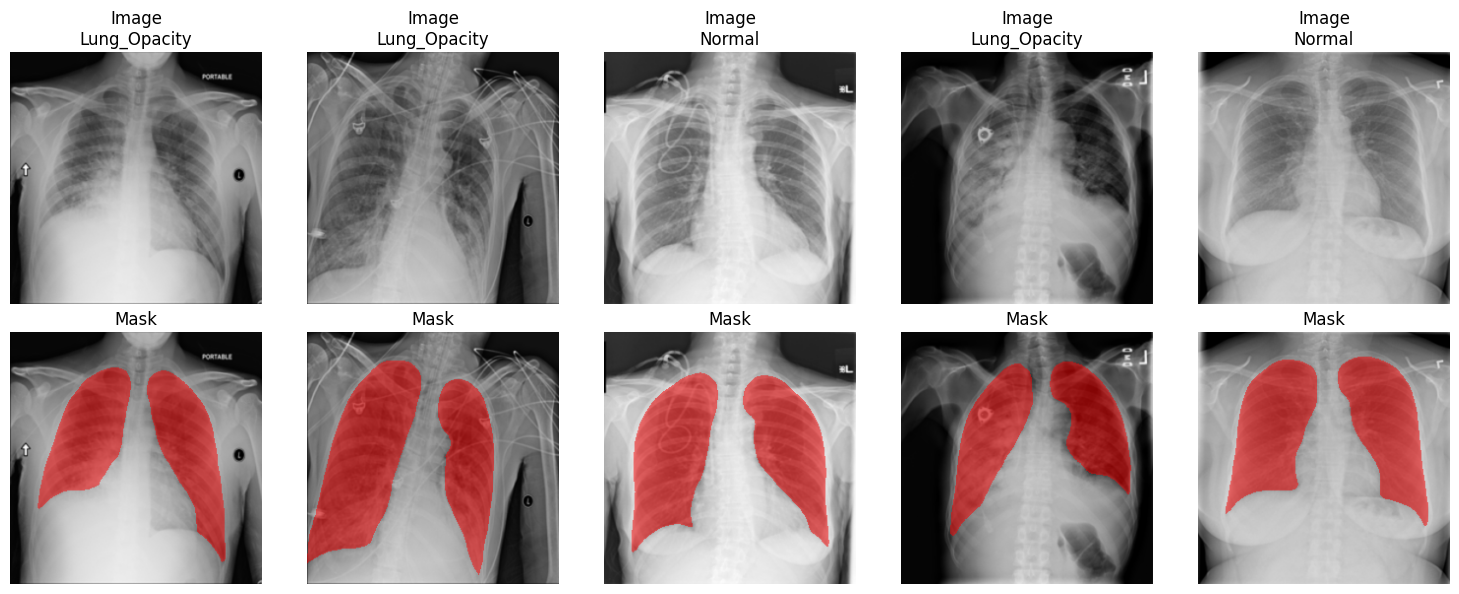

In [16]:
def plot_batch(img_batch, mask_batch , label_batch):
    plt.figure(figsize=(15, 6))

    for i in range(5): 
        mask = mask_batch[i].to(dtype = torch.bool)

        masks_over_img = tv.utils.draw_segmentation_masks(
            image = img_batch[i] , 
            masks = mask , 
            alpha = 0.5 , 
            colors = ["red"]
        )

        img = torch.permute(img_batch[i] , (1,2,0))
        img = img.numpy()
        masks_over_img = torch.permute(masks_over_img , (1,2,0))
        masks_over_img = masks_over_img.numpy()
        label = label_batch[i].item()
        label = id2label[label]

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Image\n{label}")
        plt.axis("off")
        
        plt.subplot(2, 5, i + 6)
        plt.imshow(masks_over_img)
        plt.title("Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


img_batch, mask_batch , label_batch = next(iter(val_ds))
plot_batch(img_batch, mask_batch , label_batch)

# Model


In [17]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [18]:
NUM_CLASSES = 4

In [19]:
class UNET(nn.Module) : 
    def __init__(self , num_classes) : 
        super(UNET , self).__init__() 
        
        self.enc_layer = nn.Sequential(
            nn.Conv2d(3 , 32 , kernel_size = 3 , stride = 1 , padding = 1) , 
            nn.BatchNorm2d(32) , 
            nn.ReLU(inplace = True)
        )
        
        self.encoders = nn.ModuleList([
            self.ConvBlock(32 , 64) , 
            self.ConvBlock(64 , 128) , 
            self.ConvBlock(128 , 256) , 
            self.ConvBlock(256 , 512)
        ])

        self.pool = nn.MaxPool2d(2) 

        self.bottleneck = self.ConvBlock(512, 1024) 

        self.decoders = nn.ModuleList([
            self.ConvBlock(1024, 512) , 
            self.ConvBlock(512, 256) , 
            self.ConvBlock(256, 128) , 
            self.ConvBlock(128, 64)
        ])

        self.UpSamples = nn.ModuleList([
            nn.ConvTranspose2d(1024 , 512 , kernel_size = 2 , stride = 2) , 
            nn.ConvTranspose2d(512 , 256 , kernel_size = 2 , stride = 2) , 
            nn.ConvTranspose2d(256 , 128 , kernel_size = 2 , stride = 2) , 
            nn.ConvTranspose2d(128 , 64 , kernel_size = 2 , stride = 2)
        ])

        self.mask_fc = nn.Conv2d(64, 1, kernel_size=1, stride=1)
        self.cls_fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),         
            nn.Flatten(),                  
            nn.Linear(1024, 256),       
            nn.ReLU(inplace=True),           
            nn.Linear(256, num_classes)      
        )

    def ConvBlock(self , in_channels , out_channels) : 
        return nn.Sequential(
            nn.Conv2d(in_channels , out_channels , kernel_size = 3 , stride = 1 , padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace = True),

            nn.Conv2d(out_channels , out_channels , kernel_size = 3 , stride = 1 , padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace = True)
        )

    def forward(self , x) : 
        resduials = [] 

        # Encoder Block
        x = self.enc_layer(x) 
        
        for enc in self.encoders : 
            x = enc(x)
            resduials.append(x)
            x = self.pool(x)

        x = self.bottleneck(x) 
        x_botttleneck = x

        # Decoder Block 
        for idx , dec in enumerate(self.decoders) : 
            x = self.UpSamples[idx](x)
            resduial = resduials.pop() 
            x = torch.cat([x, resduial], dim=1) 
            x = dec(x) 

        mask_output = self.mask_fc(x) 
        cls_output = self.cls_fc(x_botttleneck)

        return mask_output, cls_output

In [20]:
torch.cuda.empty_cache()
model = UNET(num_classes=NUM_CLASSES).to(DEVICE)

In [21]:
# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 31,324,613
Trainable parameters : 31,324,613


In [22]:
# test
dummy_input = torch.randn(16, 3, 256, 256 , device = DEVICE)
mask_preds, cls_preds = model(dummy_input)

print(f"Mask Predictions Shape: {mask_preds.shape}") 
print(f"Class Predictions Shape: {cls_preds.shape}") 

Mask Predictions Shape: torch.Size([16, 1, 256, 256])
Class Predictions Shape: torch.Size([16, 4])


# Train the model


In [23]:
iou_metric = tm.classification.BinaryJaccardIndex().to(DEVICE)
optim = torch.optim.Adam(model.parameters() , lr = 0.005)

In [24]:
class LossFunction(nn.Module): 
    def __init__(self, mask_weight=1.0, cls_weight=1.0): 
        super(LossFunction, self).__init__()
        self.mask_weight = mask_weight
        self.cls_weight = cls_weight

        self.mask_loss_fn = nn.BCEWithLogitsLoss()
        self.cls_loss_fn = nn.CrossEntropyLoss()

    def forward(self, mask_preds, mask_targets, cls_preds, cls_targets): 
        mask_loss = self.mask_loss_fn(mask_preds, mask_targets)
        cls_loss = self.cls_loss_fn(cls_preds, cls_targets)
        
        total_loss = (self.mask_weight * mask_loss) + (self.cls_weight * cls_loss)
        
        return total_loss, mask_loss, cls_loss

criterion = LossFunction()

In [25]:
EPOCHS = 10

In [26]:
def evaluation_per_epoch(model, data_loader, loss_fn, metric): 
    model.eval()
    metric.reset()
    with torch.inference_mode(): 
        eval_loss, epoch_mask_loss, epoch_cls_loss = 0.0, 0.0, 0.0
        for images, masks, labels in data_loader: 
            images, masks, labels = images.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
            mask_preds , label_preds = model(images)

            total_loss, mask_loss, cls_loss = loss_fn(mask_preds, masks, label_preds, labels)

            eval_loss += total_loss.item()
            epoch_mask_loss += mask_loss.item()
            epoch_cls_loss += cls_loss.item()

            mask_preds = (torch.sigmoid(mask_preds) > 0.5).float()
            metric.update(mask_preds, masks)

    eval_loss /= len(data_loader)
    epoch_mask_loss /= len(data_loader)
    epoch_cls_loss /= len(data_loader)
    eval_iou = metric.compute()
    eval_iou = eval_iou.item()
    return eval_loss, epoch_mask_loss, epoch_cls_loss, eval_iou

In [27]:
def train(
    model,
    train_ds,
    val_ds,
    optimizer,
    loss_fn,
    metric,
    epochs
): 
    model_metric = {
    "epoch": [],
    "loss": [],
    "mask_loss": [],
    "class_loss": [],
    "val_loss": [],
    "val_mask_loss": [],
    "val_class_loss": [],
    "val_iou": []
    }

    for epoch in tqdm(range(epochs)): 
        # TRAINING
        model.train()
        epoch_loss, train_mask_loss, train_cls_loss = 0.0, 0.0, 0.0
        for images, masks, labels in train_ds: 
            optimizer.zero_grad()

            images, masks, labels = images.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
            mask_preds , label_preds = model(images)

            total_loss, mask_loss, cls_loss = loss_fn(mask_preds, masks, label_preds, labels)

            total_loss.backward()
            optimizer.step()

            epoch_loss += total_loss.item()
            train_mask_loss += mask_loss.item()
            train_cls_loss += cls_loss.item()

        epoch_loss /= len(train_ds)
        train_mask_loss /= len(train_ds)
        train_cls_loss /= len(train_ds)

        # EVALUATION
        print(f"\n>>> Running evaluation ...")
        eval_loss, eval_mask_loss, eval_cls_loss, eval_iou = evaluation_per_epoch(model, val_ds, loss_fn, metric)
        
        print(f"""\nEpoch: [{epoch+1}/{epochs}]
        Loss: {epoch_loss:.4f}
        Mask Loss: {train_mask_loss:.4f}
        Class Loss: {train_cls_loss:.4f}
        Eval Loss: {eval_loss:.4f}
        Eval Mask Loss: {eval_mask_loss:.4f}
        Eval Class Loss: {eval_cls_loss:.4f}
        Eval IOU: {eval_iou:.4f}
        """)

        model_metric['epoch'].append(epoch+1)
        model_metric["loss"].append(epoch_loss)
        model_metric["mask_loss"].append(train_mask_loss)
        model_metric["class_loss"].append(train_cls_loss)
        model_metric["val_loss"].append(eval_loss)
        model_metric["val_mask_loss"].append(eval_mask_loss)
        model_metric["val_class_loss"].append(eval_cls_loss)
        model_metric["val_iou"].append(eval_iou)
        
    return model_metric

In [28]:
model_metric = train(
    model,
    train_ds, 
    val_ds, 
    optim, 
    criterion,
    iou_metric,
    EPOCHS
)

  0%|          | 0/10 [00:00<?, ?it/s]


>>> Running evaluation ...


 10%|█         | 1/10 [07:52<1:10:49, 472.19s/it]


Epoch: [1/10]
        Loss: 1.0658
        Mask Loss: 0.1591
        Class Loss: 0.9067
        Eval Loss: 1.4136
        Eval Mask Loss: 0.3536
        Eval Class Loss: 1.0599
        Eval IOU: 0.5188
        

>>> Running evaluation ...


 20%|██        | 2/10 [15:44<1:02:56, 472.00s/it]

...


Epoch: [8/10]
        Loss: 0.2237
        Mask Loss: 0.0250
        Class Loss: 0.1987
        Eval Loss: 0.2756
        Eval Mask Loss: 0.0254
        Eval Class Loss: 0.2502
        Eval IOU: 0.9581
        

>>> Running evaluation ...


 90%|█████████ | 9/10 [1:10:45<07:51, 471.61s/it]


Epoch: [9/10]
        Loss: 0.2060
        Mask Loss: 0.0234
        Class Loss: 0.1826
        Eval Loss: 0.3809
        Eval Mask Loss: 0.0324
        Eval Class Loss: 0.3484
        Eval IOU: 0.9476
        

>>> Running evaluation ...


100%|██████████| 10/10 [1:18:37<00:00, 471.71s/it]


Epoch: [10/10]
        Loss: 0.1841
        Mask Loss: 0.0224
        Class Loss: 0.1617
        Eval Loss: 0.3221
        Eval Mask Loss: 0.0306
        Eval Class Loss: 0.2915
        Eval IOU: 0.9499
        


In [29]:
model_metric = pd.DataFrame(model_metric)
model_metric

,epoch,loss,mask_loss,class_loss,val_loss,val_mask_loss,val_class_loss,val_iou
0,1,1.065829,0.159142,0.906687,1.413574,0.353644,1.059930,0.518763
1,2,0.700797,0.073887,0.626911,0.756666,0.097808,0.658858,0.838589
2,3,0.501950,0.051567,0.450383,0.475235,0.048560,0.426675,0.922960
3,4,0.390857,0.040456,0.350401,0.374688,0.042721,0.331968,0.930244
4,5,0.324992,0.033231,0.291761,0.416305,0.034635,0.381670,0.943429
5,6,0.275711,0.029104,0.246607,0.295712,0.030536,0.265176,0.950858
6,7,0.241689,0.026694,0.214995,0.272778,0.026934,0.245843,0.955925
7,8,0.223664,0.024958,0.198706,0.275644,0.025400,0.250244,0.958108
8,9,0.206037,0.023436,0.182601,0.380850,0.032422,0.348428,0.947608
9,10,0.184095,0.022351,0.161744,0.322066,0.030568,0.291498,0.949891


Final Epoch Metrics:
epoch             10.000000
loss               0.184095
mask_loss          0.022351
class_loss         0.161744
val_loss           0.322066
val_mask_loss      0.030568
val_class_loss     0.291498
val_iou            0.949891
Name: 9, dtype: float64


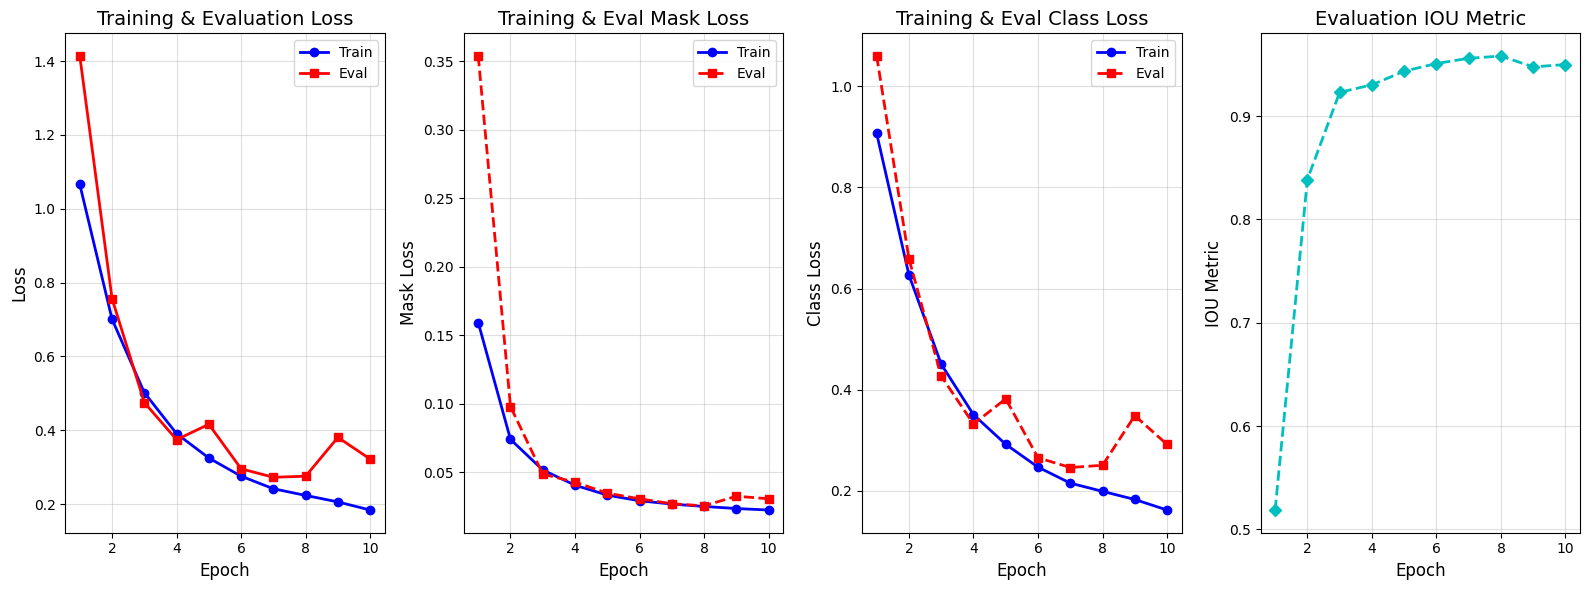

In [39]:
print("Final Epoch Metrics:")
print(model_metric.iloc[-1])

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 6))
epochs = model_metric["epoch"]

ax1.plot(epochs, model_metric["loss"], color='blue', marker='o', linestyle='-', label='Train', linewidth=2)
ax1.plot(epochs, model_metric["val_loss"], color='red', marker='s', linestyle='-', label='Eval', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Evaluation Loss', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.4)

ax2.plot(epochs, model_metric["mask_loss"], color='blue', marker='o', linestyle='-', label='Train', linewidth=2)
ax2.plot(epochs, model_metric["val_mask_loss"], color='red', marker='s', linestyle='--', label='Eval', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Mask Loss', fontsize=12)
ax2.set_title('Training & Eval Mask Loss', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.4)

ax3.plot(epochs, model_metric["class_loss"], color='blue', marker='o', linestyle='-', label='Train', linewidth=2)
ax3.plot(epochs, model_metric["val_class_loss"], color='red', marker='s', linestyle='--', label='Eval', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Class Loss', fontsize=12)
ax3.set_title('Training & Eval Class Loss', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.4)

ax4.plot(epochs, model_metric["val_iou"], 'c--D', linewidth=2)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('IOU Metric', fontsize=12)
ax4.set_title('Evaluation IOU Metric', fontsize=14)
ax4.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('training_and_eval_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate the model


In [40]:
eval_loss, eval_mask_loss, eval_cls_loss, eval_iou = evaluation_per_epoch(model, val_ds, criterion, iou_metric)

In [41]:
print(f"""Evaluation Result:
        Eval Loss: {eval_loss:.4f}
        Eval Mask Loss: {eval_mask_loss:.4f}
        Eval Class Loss: {eval_cls_loss:.4f}
        Eval IOU: {eval_iou:.4f}
        """)

Evaluation Result:
        Eval Loss: 0.3221
        Eval Mask Loss: 0.0306
        Eval Class Loss: 0.2915
        Eval IOU: 0.9499
        


In [ ]:
# Save model
torch.save(model.state_dict(), 'best_model.pth')

# Inference


In [ ]:
# load model for inference
weights_path = 'best_model.pth'
model.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))

<All keys matched successfully>

In [67]:
test_images = [
    os.path.join(BASE_DIR, "Normal",'images','Normal-10021.png'),
    os.path.join(BASE_DIR, "Lung_Opacity",'images','Lung_Opacity-1013.png'),
    os.path.join(BASE_DIR, "Viral Pneumonia",'images','Viral Pneumonia-1021.png'),
    os.path.join(BASE_DIR, "COVID",'images','COVID-1040.png'),
]

In [70]:
transforms = get_transform()

In [82]:
def inference(model, img_path, transforms): 
    image = tv.io.read_image(img_path, mode=tv.io.ImageReadMode.RGB)
    image = tv_tensors.Image(image)
    image = transforms(image)
    image = image.unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.inference_mode(): 
        mask_prediction , class_prediction = model(image)

    # class prediction probability
    class_probs = torch.softmax(class_prediction, dim=1)

    # class prediction highest probability
    pred_class_id = torch.argmax(class_probs, dim=1).item()

    confidence = class_probs[0, pred_class_id].item()
    pred_class_name = id2label[pred_class_id]

    mask_prob = torch.sigmoid(mask_prediction)
    mask_pred = (mask_prob > 0.5).float()
    mask_pred = mask_pred.squeeze().cpu().numpy()

    return pred_class_name, confidence, mask_pred

In [99]:
def plot_predictions(model, test_images, transforms) : 
    for img_path in test_images : 
        pred_class_name, confidence, mask_pred = inference(model , img_path , transforms)

        image = tv.io.read_image(img_path, mode=tv.io.ImageReadMode.RGB)
        image = tv_tensors.Image(image)
        image = transforms(image)

        mask = torch.from_numpy(mask_pred)
        mask = mask.to(dtype = torch.bool)

        masks_over_img = tv.utils.draw_segmentation_masks(
            image = image , 
            masks = mask , 
            alpha = 0.5 , 
            colors = ["blue"]
        )

        image = torch.permute(image , (1,2,0))
        image = image.numpy()
        masks_over_img = torch.permute(masks_over_img , (1,2,0))
        masks_over_img = masks_over_img.numpy()

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(image)
        axes[0].set_title("Original X-Ray")
        axes[0].axis("off")
        
        axes[1].imshow(mask_pred, cmap='gray')
        axes[1].set_title("Predicted Mask")
        axes[1].axis("off")
        
        axes[2].imshow(masks_over_img)
        axes[2].set_title(f"Overlay\n{pred_class_name} ({confidence*100:.1f}%)")
        axes[2].axis("off")
        
        plt.tight_layout()
        plt.show()

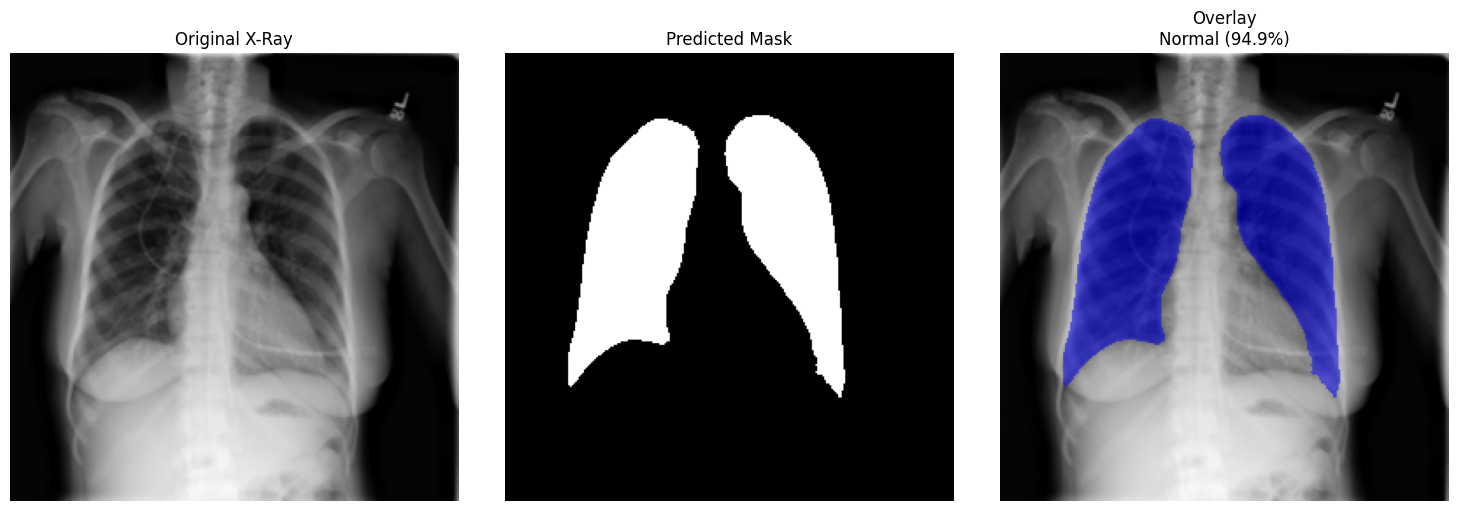

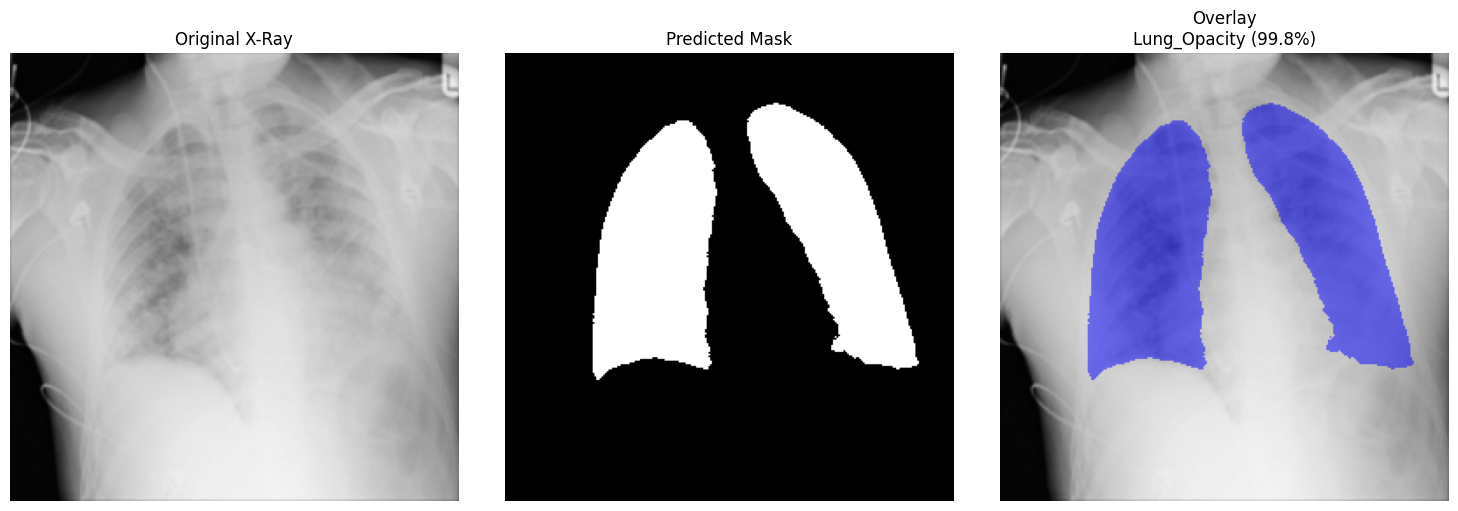

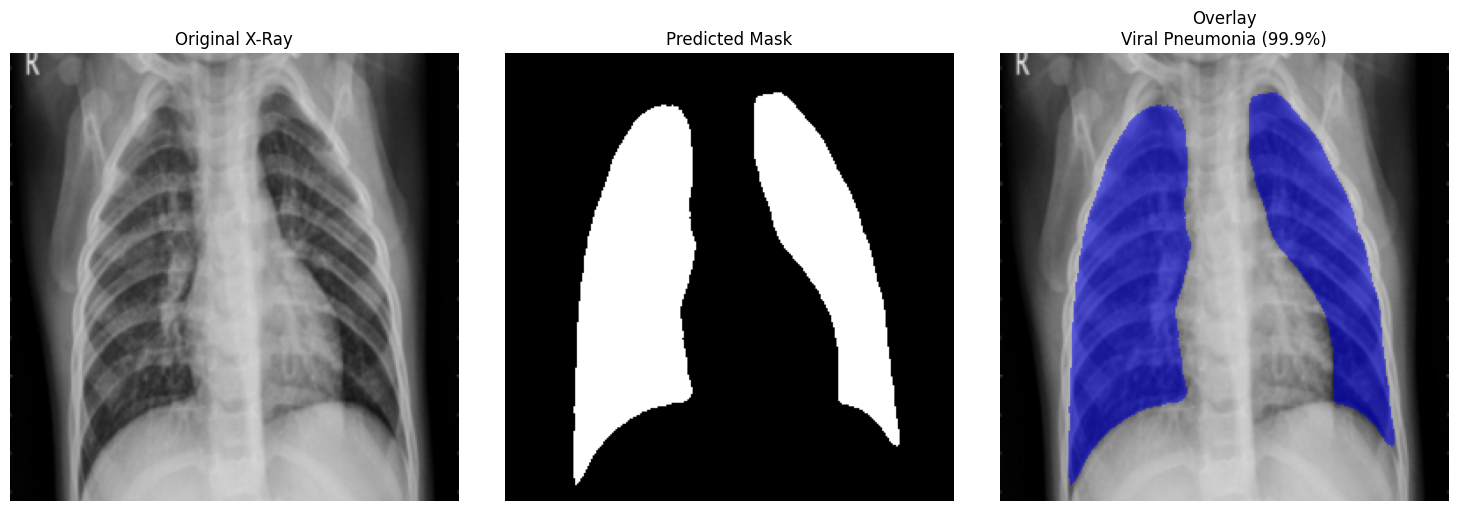

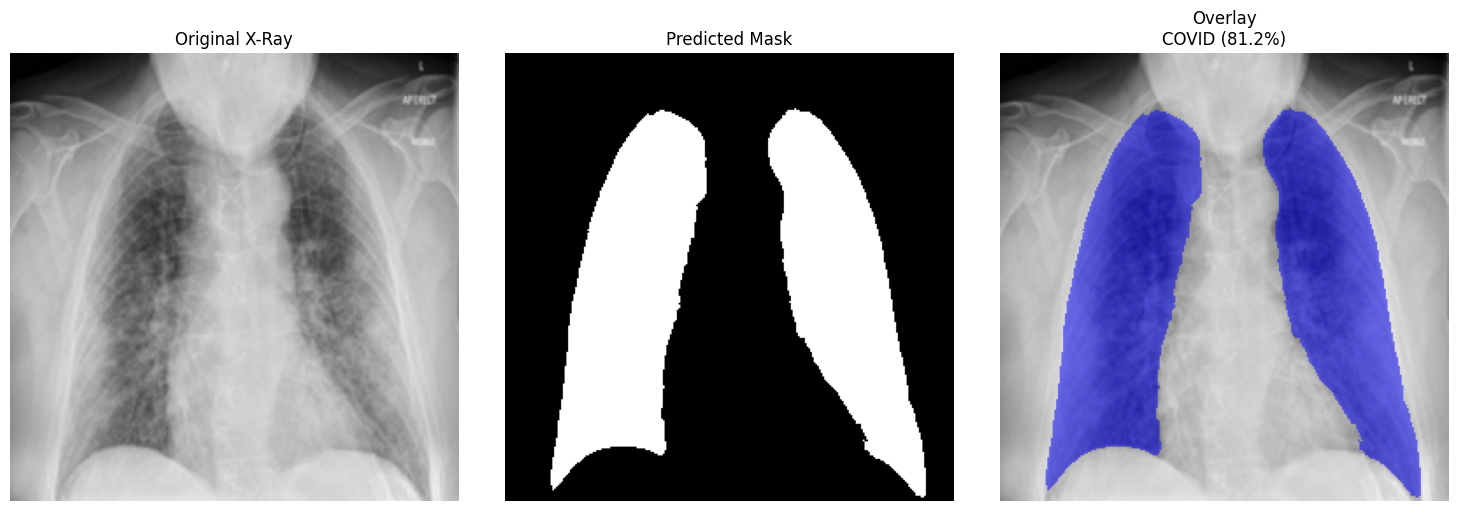

In [100]:
plot_predictions(model, test_images, transforms)